In [1]:
!pip install scikit-learn
from sklearn.model_selection import train_test_split
import requests
import pandas as pd
from tqdm import tqdm
import tmdbdata as td

Récupération des données 

In [2]:
ids= td.get_movie_ids_list(3, headers=td.headers)
df=td.get_movies_info(ids,headers=td.headers)
df1=td.drop_useless_info(df)
df1=td.keep_main_genre(df1)
df1=td.full_poster_path(df1)
df1.head()
df1.describe()
df1.shape

getting movie ids


100%|██████████| 3/3 [00:01<00:00,  1.78it/s]


getting movie info


100%|██████████| 60/60 [00:07<00:00,  8.08it/s]


(60, 13)

On remarque que qu'il y'a des données où le budget n'est pas renseigné, en effet on a min budget égal à 0.

In [6]:
df1=df1.loc[df1["budget"]!=0] # on supprime les lignes où le budget n'est pas renseigné, l'imputation est possible par le budget moyen, pour le moment on fait le choix de ne pas imputer
df1.shape

(49, 27)

On va créer une colonne comptant le nombre de mots caractères dans le synopsis 

In [7]:
df1["overview_count"]=df1["overview"].map(len)
df1.head()
df1.shape

/tmp/ipykernel_38827/956769132.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1["overview_count"]=df1["overview"].map(len)


(49, 27)

Nous allons encoder les genres pour la regression linéaire : méthode one hot encoding

In [8]:
df1["main_genre_name"].unique() 

array(['Drama', 'Comedy', 'Romance', 'Family', 'Adventure', 'Horror',
       'Action', 'Thriller', 'Fantasy', 'Animation', 'Music', 'Crime',
       'History'], dtype=object)

In [12]:
#Méthode : OneHotEncoder
for genre in df1["main_genre_name"].unique() :
    df1["main_genre_name"+"_"+str(genre)] = (df1["main_genre_name"] == genre).astype(int) 
df1.shape
df1.head()

/tmp/ipykernel_38827/4039880569.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1["main_genre_name"+"_"+str(genre)] = (df1["main_genre_name"] == genre).astype(int)
/tmp/ipykernel_38827/4039880569.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1["main_genre_name"+"_"+str(genre)] = (df1["main_genre_name"] == genre).astype(int)
/tmp/ipykernel_38827/4039880569.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = 

,budget,id,overview,popularity,release_date,revenue,runtime,title,vote_average,vote_count,...,main_genre_name_Family,main_genre_name_Adventure,main_genre_name_Horror,main_genre_name_Action,main_genre_name_Thriller,main_genre_name_Fantasy,main_genre_name_Animation,main_genre_name_Crime,main_genre_name_Music,main_genre_name_History
0,13000000,77338,A true story of two men who should never have ...,44.588,2011-11-02,426590315,113,The Intouchables,8.276,17209,...,0,0,0,0,0,0,0,0,0,0
1,10000000,194,"At a tiny Parisian café, the adorable yet pain...",45.387,2001-04-25,173921954,122,Amélie,7.914,11494,...,0,0,0,0,0,0,0,0,0,0
2,4300000,152584,"Adèle's life is changed when she meets Emma, a...",35.826,2013-10-09,19465835,180,Blue Is the Warmest Color,7.089,4556,...,0,0,0,0,0,0,0,0,0,0
3,2600000,406,After a chaotic night of rioting in a marginal...,27.171,1995-05-31,15300000,98,La Haine,8.092,4038,...,0,0,0,0,0,0,0,0,0,0
4,58500000,2899,The Egyptian Queen Cleopatra bets against the ...,28.874,2002-01-30,128027976,108,Asterix & Obelix: Mission Cleopatra,7.389,3494,...,1,0,0,0,0,0,0,0,0,0


Nous allons essayer de prédire la note c'est à dire vote_average à partir des variables suivantes :

In [13]:
df1["main_genre_name"].unique()
L=[]
for i in df1["main_genre_name"].unique() : 
    L.append("main_genre_name"+"_"+str(i))
print(L)

var_explicative=["id","vote_average","budget","runtime","overview_count"]
var_explicative.extend(L)
df1=df1.loc[:,var_explicative]
df1.head(1)


['main_genre_name_Drama', 'main_genre_name_Comedy', 'main_genre_name_Romance', 'main_genre_name_Family', 'main_genre_name_Adventure', 'main_genre_name_Horror', 'main_genre_name_Action', 'main_genre_name_Thriller', 'main_genre_name_Fantasy', 'main_genre_name_Animation', 'main_genre_name_Music', 'main_genre_name_Crime', 'main_genre_name_History']


,id,vote_average,budget,runtime,overview_count,main_genre_name_Drama,main_genre_name_Comedy,main_genre_name_Romance,main_genre_name_Family,main_genre_name_Adventure,main_genre_name_Horror,main_genre_name_Action,main_genre_name_Thriller,main_genre_name_Fantasy,main_genre_name_Animation,main_genre_name_Music,main_genre_name_Crime,main_genre_name_History
0,77338,8.276,13000000,113,154,1,0,0,0,0,0,0,0,0,0,0,0,0


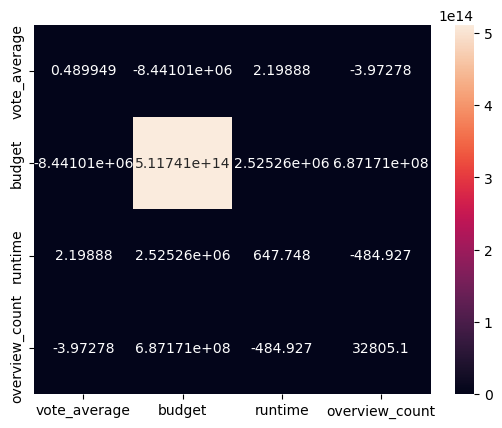

In [16]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

cov = np.cov(df1.loc[:,["vote_average","budget","runtime","overview_count"]].T, bias=True)
labs = ['vote_average', 'budget', 'runtime',"overview_count"]

sns.heatmap(cov, annot=True, fmt='g', xticklabels=labs, yticklabels=labs)
plt.show()


/tmp/ipykernel_38827/2385372420.py:1: DeprecationWarning: bias and ddof have no effect and are deprecated
  corr = np.corrcoef(df1.loc[:,["vote_average","budget","runtime","overview_count"]].T, bias=True)


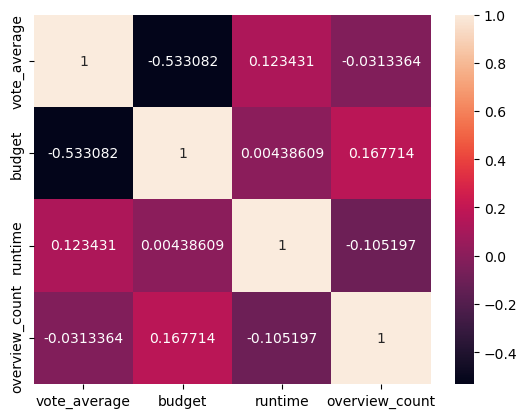

In [17]:


corr = np.corrcoef(df1.loc[:,["vote_average","budget","runtime","overview_count"]].T, bias=True)
labs = ['vote_average', 'budget', 'runtime',"overview_count"]

sns.heatmap(corr, annot=True, fmt='g', xticklabels=labs, yticklabels=labs)
plt.show()

Si on rajoute main_genre_name_Drama :

/tmp/ipykernel_38827/4188107850.py:1: DeprecationWarning: bias and ddof have no effect and are deprecated
  corr = np.corrcoef(df1.loc[:,["vote_average","budget","runtime","overview_count","main_genre_name_Drama"]].T, bias=True)


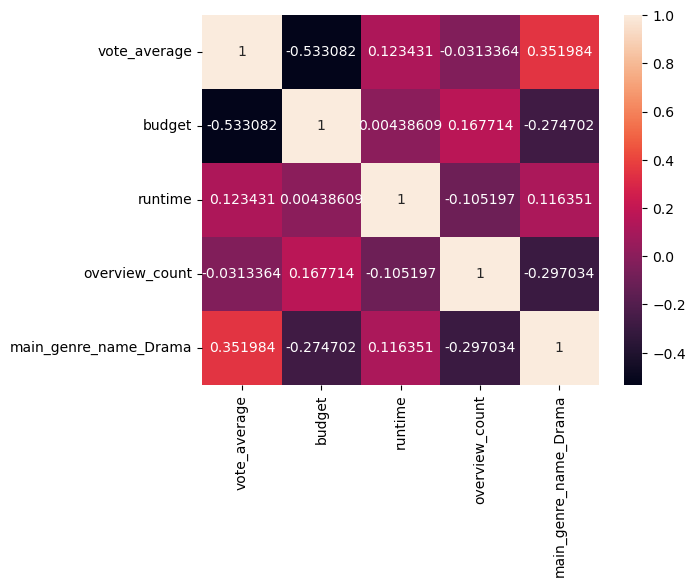

In [19]:
corr = np.corrcoef(df1.loc[:,["vote_average","budget","runtime","overview_count","main_genre_name_Drama"]].T, bias=True)
labs = ['vote_average', 'budget', 'runtime',"overview_count","main_genre_name_Drama"]

sns.heatmap(corr, annot=True, fmt='g', xticklabels=labs, yticklabels=labs)
plt.show()

Normalisation et Standardisation des données : pas nécessaire dans la regression linéaire car le modèle ne sélectionne pas en fonction des poids, ce qui arrive dans les modèles de clustering. 

Régression linéaire :

In [ ]:
X=df1.loc[:,~df1.columns.isin(['id', 'vote_average']) ]
Y=df1[["vote_average"]]
X.head()
Y.head()
#random_state=42, vous vous assurez que la division des données sera la même à chaque exécution du code. Cela est particulièrement utile pour la reproductibilité des expériences, car cela garantit que vous obtenez exactement les mêmes ensembles d'entraînement et de test chaque fois que vous exécutez votre code.

,vote_average
0,8.276
1,7.914
2,7.089
3,8.092
4,7.389
